# Lab 4 (February 10, 2026)
## Part 1. Vector workflow (GeoPandas)
### 1.1 Read + inspect

In [1]:
import geopandas as gpd
import rasterio

print('GeoPandas version:', gpd.__version__)
print('rasterio version:', rasterio.__version__)

GeoPandas version: 1.1.2
rasterio version: 1.4.4


In [16]:
study = gpd.read_file("data/raw/Seoul.geojson")
vec = gpd.read_file("data/raw/Seoul_stream.geojson")

print("Study CRS:", study.crs)
print("Study bounds:", study.total_bounds)
print("Vector CRS:", vec.crs)
print("Vector bounds:", vec.total_bounds)
print(vec.head())

Study CRS: EPSG:5179
Study bounds: [ 935017.06295    1936687.2501      972046.19523333 1966977.37505   ]
Vector CRS: EPSG:5179
Vector bounds: [ 935238.6855 1937726.3403  971597.7799 1965815.0104]
   OBJECTID      CODE2                      INDEXPAGE1 LEVEL1 NAME2  RIVLEN1  \
0         1  1005380.0                          ,43,59   ,43,  ,Ⱦ3õ    20.70   
1         2  1500321.0                             ,41    ,41  ,ƶ1õ    18.80   
2         3  1000010.0  ,25,41,43,45,61,63,79,81,97,99   ,25,   ,Ѱ5   265.36   
3         4  1000010.0  ,25,41,43,45,61,63,79,81,97,99   ,25,   ,Ѱ5   265.36   
4         5  1000010.0  ,25,41,43,45,61,63,79,81,97,99   ,25,   ,Ѱ5   265.36   

   UID1 INDEXPAGE2 LEVEL2  RIVLEN2  ...  UID2 CODE1  INDEXPAGE  LEVEL NAME1  \
0  22.0        NaN    NaN      0.0  ...   0.0   0.0        NaN    NaN   NaN   
1   0.0        NaN    NaN      0.0  ...   0.0   0.0        NaN    NaN   NaN   
2  49.0        NaN    NaN      0.0  ...   0.0   0.0        NaN    NaN   NaN   
3  49.0

### 1.2 CRS workflow (detect -> verify -> transform)

In [4]:
WORK_EPSG = "EPSG:5179"
study_m = study.to_crs(WORK_EPSG)
vec_m = vec.to_crs(WORK_EPSG)

### 1.3 Clip + basic aggregation

In [5]:
vec_clip = gpd.clip(vec_m, study_m)

In [6]:
vec_clip.head()

,OBJECTID,CODE2,INDEXPAGE1,LEVEL1,NAME2,RIVLEN1,UID1,INDEXPAGE2,LEVEL2,RIVLEN2,...,UID2,CODE1,INDEXPAGE,LEVEL,NAME1,RIVLEN,UID,Shape_Leng,Shape_Area,geometry
9,10,0.0,NaN,NaN,NaN,0.0,0.0,",59",",59",2.78,...,567.0,0.0,NaN,NaN,NaN,0.0,0.0,4133.578257,4128.052017,"POLYGON ((947156.823 1939627, 947385.79 193945..."
14,15,0.0,NaN,NaN,NaN,0.0,0.0,",59",",59",12.50,...,547.0,0.0,NaN,NaN,NaN,0.0,0.0,1174.814069,6792.688640,"MULTIPOLYGON (((942122.937 1941902.747, 942123..."
19,20,0.0,NaN,NaN,NaN,0.0,0.0,",43,59",",43,2",11.00,...,537.0,0.0,NaN,NaN,NaN,0.0,0.0,22399.799248,119260.198646,"POLYGON ((946409.766 1945567.504, 946416.354 1..."
13,14,0.0,NaN,NaN,NaN,0.0,0.0,",59",",59",4.85,...,549.0,0.0,NaN,NaN,NaN,0.0,0.0,6286.402858,6279.463204,"POLYGON ((944075.693 1944022.607, 943973.244 1..."
0,1,1005380.0,",43,59",",43,",",Ⱦ3õ",20.7,22.0,NaN,NaN,0.00,...,0.0,0.0,NaN,NaN,NaN,0.0,0.0,30425.734479,867204.802127,"MULTIPOLYGON (((945990.514 1940366.319, 945991..."


In [17]:
if vec_clip.geom_type.isin(["Polygon", "MultiPolygon"]).any():
    vec_clip["area_m2"] = vec_clip.area
    print("Total area (km^2):", vec_clip["area_m2"].sum() / 1e6)

vec_clip.to_file('data/outputs/vector_clipped.gpkg', layer='vector_clipped', driver='GPKG')

Total area (km^2): 32.94774154304325


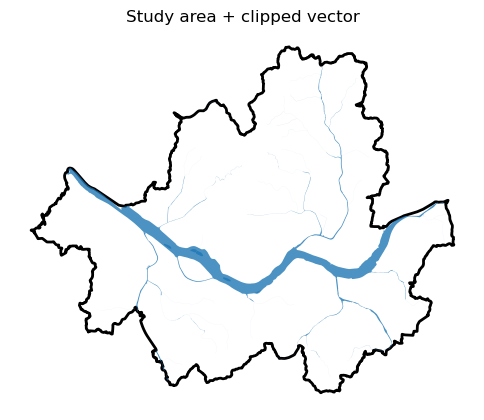

In [18]:
import matplotlib.pyplot as plt

ax = study_m.plot(facecolor='none', edgecolor='black', linewidth=2, figsize=(6,8))
vec_clip.plot(ax=ax, linewidth=0.8, alpha=0.8)
ax.set_title('Study area + clipped vector')
ax.set_axis_off()
plt.show()

## Part 2. Raster workflow (rasterio)
### 2.1 Open + inspect metadata

In [8]:
import numpy as np
import rasterio

In [9]:
raster_path = "data/raw/ndvi_seoul_prj.tif"

with rasterio.open(raster_path) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("Transform:", src.transform)
    print("Resolution:", (src.transform.a, -src.transform.e))
    print("Nodata:", src.nodata)
    print("Count:", src.count, "dtype:", src.dtypes)

CRS: EPSG:5179
Bounds: BoundingBox(left=934506.1991, bottom=1935687.1091, right=972682.3497, top=1967008.0463)
Transform: | 17.18, 0.00, 934506.20|
| 0.00,-17.18, 1967008.05|
| 0.00, 0.00, 1.00|
Resolution: (17.18098586858688, 17.18098584750414)
Nodata: -1.0
Count: 1 dtype: ('float32',)


### 2.2 Plot a raster preview + nodata-aware stats

min/mean/max: -0.6730159 0.23757938 1.0


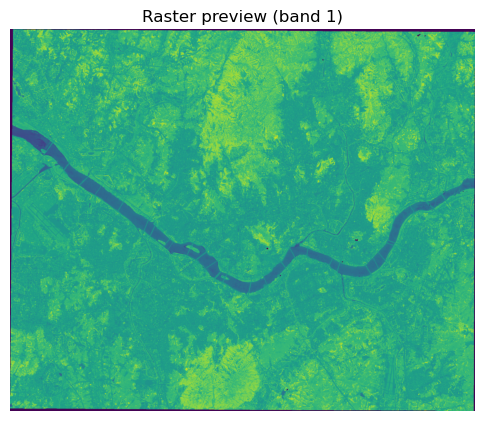

In [19]:
import matplotlib.pyplot as plt

with rasterio.open("data/raw/ndvi_seoul_prj.tif") as src:
    band1 = src.read(1)
    nod = src.nodata
    data = np.where(band1 == nod, np.nan, band1) if nod is not None else band1

    print("min/mean/max:", np.nanmin(data), np.nanmean(data), np.nanmax(data))

    plt.figure(figsize=(6, 8))
    plt.imshow(band1)
    plt.title("Raster preview (band 1)")
    plt.axis("off")
    plt.show()

### 2.3 Mask/clip raster by polygon

In [11]:
from rasterio.mask import mask

In [12]:
with rasterio.open(raster_path) as src:
    study_r = study.to_crs(src.crs)
    shapes = [g.__geo_interface__ for g in study_r.geometry]

    out_img, out_transform = mask(src, shapes, crop=True)
    out_meta = src.meta.copy()
    out_meta.update(
        {
            "height": out_img.shape[1],
            "width": out_img.shape[2],
            "transform": out_transform,
        }
    )

clipped_path = 'data/outputs/raster_clipped.tif'
with rasterio.open(clipped_path, 'w', **out_meta) as dst:
    dst.write(out_img)

print('Saved:', clipped_path)

Saved: data/outputs/raster_clipped.tif


min/mean/max: -0.6004078 0.20944287 1.0


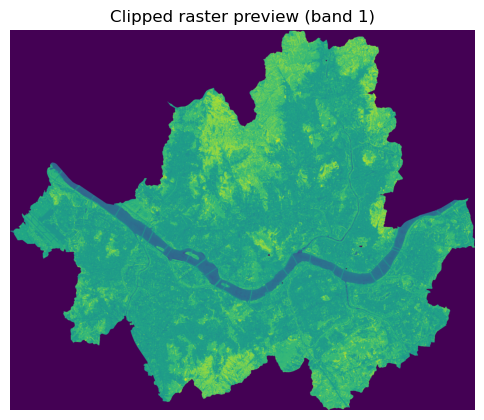

In [21]:
with rasterio.open(clipped_path) as src:
    band1 = src.read(1)
    nod = src.nodata
    data = np.where(band1 == nod, np.nan, band1) if nod is not None else band1

    print("min/mean/max:", np.nanmin(data), np.nanmean(data), np.nanmax(data))

    plt.figure(figsize=(6, 8))
    plt.imshow(band1)
    plt.title("Clipped raster preview (band 1)")
    plt.axis("off")
    plt.show()

## Part 3. Integration: sample raster values at points
### 3.1 Create random points inside the study area (GeoPandas)

In [13]:
from shapely.geometry import Point
import random
import geopandas as gpd
import rasterio

with rasterio.open(clipped_path) as src:
    crs_r = src.crs

study_r = study.to_crs(crs_r)
poly = study_r.geometry.union_all()

N = 50
minx, miny, maxx, maxy = poly.bounds

pts_list = []
while len(pts_list) < N:
    x = random.uniform(minx, maxx)
    y = random.uniform(miny, maxy)
    p = Point(x, y)
    if poly.contains(p):
        pts_list.append(p)

pts = gpd.GeoDataFrame({'id': range(1, N+1)}, geometry=pts_list, crs=crs_r)

### 3.2 Sample raster at those points (rasterio)

In [14]:
with rasterio.open(clipped_path) as src:
    coords = [(g.x, g.y) for g in pts.geometry]
    vals = [v[0] for v in src.sample(coords)]

pts['value'] = vals
print(pts.head())
pts.to_file('data/outputs/points_sampled.gpkg', layer='points_sampled', driver='GPKG')

   id                        geometry     value
0   1  POINT (961580.469 1951151.632)  0.132293
1   2  POINT (949477.489 1958206.341)  0.082409
2   3  POINT (941049.669 1951803.345) -0.027624
3   4  POINT (967446.954 1943685.213)  0.166343
4   5  POINT (960648.182 1961508.893)  0.231402


### 3.3 Map check: points colored by sampled value

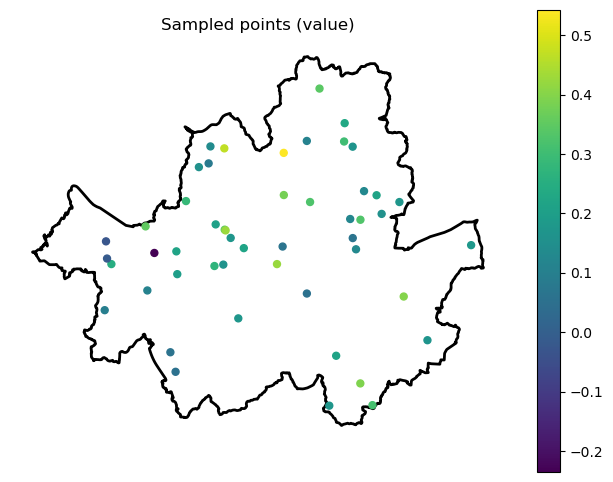

In [15]:
ax = study_r.plot(facecolor='none', edgecolor='black', linewidth=2, figsize=(8, 6))
pts.plot(ax=ax, column='value', legend=True, markersize=25)
ax.set_title('Sampled points (value)')
ax.set_axis_off()
plt.show()